# 📊 Sentiment Analysis Final Project

---

## 🎯 Project Overview

Welcome to your Sentiment Analysis final project! In this project, you will:

- 🔍 **Analyze** customer reviews or social media text data
- 🧹 **Preprocess** text data using NLP techniques
- 🤖 **Build** and compare multiple classification models
- 📈 **Evaluate** model performance using appropriate metrics
- 💼 **Communicate** findings in a business context

---

## 📋 Project Requirements

- **Dataset**: Use a public sentiment dataset (e.g., IMDb reviews, Amazon reviews, airline tweets)
- **Models**: Train at least **2 different classification models**
- **Evaluation**: Use multiple metrics (accuracy, precision, recall, confusion matrix)
- **Documentation**: Use markdown cells to explain your approach, findings, and insights

---

## 💡 Important Tips for Success

### Working with Limited Resources
- ⚡ **Start small**: Use `df.sample(n=1000)` or `df.head(5000)` to work with a subset
- 🎯 **Limit vocabulary**: Use `max_features=5000` in TfidfVectorizer
- 🚀 **Choose efficient models**: LogisticRegression and MultinomialNB are fast and effective
- 💾 **Save your work frequently**: Use Ctrl+S or Cmd+S often

### Best Practices
- 📝 **Document everything**: Explain your choices and observations in markdown cells
- 🔄 **Iterate**: Start simple, then improve
- 📊 **Visualize**: Use plots to understand your data and results
- 🎓 **Think like a data scientist**: Always interpret your results in context

---

Let's get started! 🚀

---

# Part 1: Project Definition 🎯

## Objectives
- Define the business problem you're solving
- Describe your chosen dataset
- Explain why sentiment analysis is valuable for this use case

## Instructions

In the markdown cell below, answer these questions:

1. **What is the business problem?**
   - What decision or insight will this sentiment analysis support?
   - Who would use these results?

2. **What dataset are you using?**
   - Name and source of the dataset
   - Number of samples
   - What the text represents (reviews, tweets, comments, etc.)
   - What are the sentiment labels (positive/negative, star ratings, etc.)?

3. **Why is this problem important?**
   - How could the results be used in real-world scenarios?

---

## 📝 Your Project Definition

## Business Problem

Amazon receives a very large number of customer reviews for food products. Reading every review manually would take too much time, so the goal of this project is to build a sentiment analysis model that can automatically classify reviews as positive or negative.

This analysis can help Amazon sellers, product managers, and customer-service teams understand customer satisfaction, identify common complaints, and find products that may need improvement. The results could also help businesses monitor customer opinions more efficiently.

## Dataset Description

- **Dataset name:** Amazon Fine Food Reviews
- **Source:** Kaggle
- **Original number of samples:** 568,454 reviews
- **Project sample size:** 10,000 reviews
- **Text type:** Written customer reviews of food products
- **Original labels:** Star ratings from 1 to 5
- **Sentiment labels used in this project:**
  - Ratings 1–2 = Negative
  - Ratings 4–5 = Positive
  - Rating 3 = Removed because it represents neutral or mixed sentiment

## Importance and Real-World Applications

Sentiment analysis can help businesses quickly understand how customers feel about their products. The model could be used to identify negative feedback, track customer satisfaction, compare products, and prioritize reviews that may require attention. It could also support decisions related to product quality, customer service, and marketing.

---

# Part 2: Exploratory Data Analysis (EDA) 🔍

## Objectives
- Load and examine your dataset
- Understand the distribution of sentiments
- Analyze text characteristics (length, common words, etc.)
- Identify any data quality issues

## What to Explore

✅ **Dataset structure**: Shape, columns, data types

✅ **Missing values**: Check for and handle missing data

✅ **Class distribution**: Are sentiments balanced?

✅ **Text length**: Average, min, max review lengths

✅ **Common words**: Most frequent words per sentiment

✅ **Sample reviews**: Display examples from each class

---

## 💡 Tips
- Use `.info()`, `.describe()`, and `.value_counts()` for quick insights
- Visualize distributions with bar plots and histograms
- Look for imbalanced classes that might affect model performance
- Create a word cloud to visualize common terms (optional but impressive!)

In [44]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [45]:
!pip -q install kagglehub

In [46]:
import kagglehub
import pandas as pd
import os

# Download the dataset
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

print("Dataset downloaded to:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.
Dataset downloaded to: /kaggle/input/amazon-fine-food-reviews
['hashes.txt', 'Reviews.csv', 'database.sqlite']


In [47]:
# Keep only the columns needed for sentiment analysis
df = df[['Text', 'Score']].copy()

# Remove neutral 3-star reviews
df = df[df['Score'] != 3].copy()

# Convert star ratings into sentiment labels
# Ratings 4-5 are positive, and ratings 1-2 are negative
df['sentiment'] = np.where(
    df['Score'] >= 4,
    'positive',
    'negative'
)

# Remove missing review text
df.dropna(subset=['Text', 'sentiment'], inplace=True)

# Remove duplicate reviews
df.drop_duplicates(subset=['Text'], inplace=True)

# Use a smaller sample to reduce memory and processing time in Colab
df = df.sample(n=10000, random_state=42).reset_index(drop=True)

print(f"Working dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

df.head()

Working dataset shape: (10000, 3)
Columns: ['Text', 'Score', 'sentiment']


,Text,Score,sentiment
0,"Quite flavorful, it jump starts my day! Certai...",4,positive
1,If you're still paying $3-$5 for an iced coffe...,4,positive
2,"The flavor lasts for hours, so it functions as...",5,positive
3,This is a fairly decent soup but the shrimp we...,4,positive
4,The first time we ordered this it was so good....,1,negative


In [48]:
print("--- Dataset Information ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Reviews ---")
print(df.duplicated(subset=['Text']).sum())

print("\n--- Basic Statistics ---")
print(df.describe(include='all'))

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Text       10000 non-null  object
 1   Score      10000 non-null  int64 
 2   sentiment  10000 non-null  object
dtypes: int64(1), object(2)
memory usage: 234.5+ KB

--- Missing Values ---
Text         0
Score        0
sentiment    0
dtype: int64

--- Duplicate Reviews ---
0

--- Basic Statistics ---
                                                     Text         Score  \
count                                               10000  10000.000000   
unique                                              10000           NaN   
top     I started using this years ago when it won a D...           NaN   
freq                                                    1           NaN   
mean                                                  NaN      4.267500   
std                            

In [49]:
print(f"Working with {len(df):,} Amazon food reviews")

Working with 10,000 Amazon food reviews


--- Sentiment Distribution ---
sentiment
positive    8411
negative    1589
Name: count, dtype: int64

--- Sentiment Percentages ---
sentiment
positive    84.11
negative    15.89
Name: proportion, dtype: float64


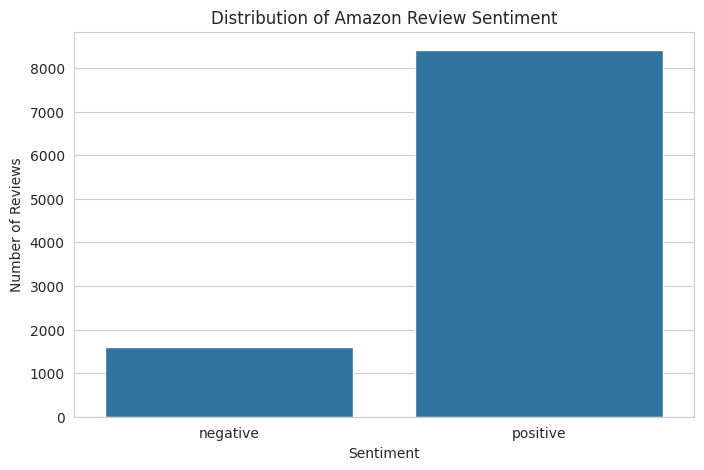

In [50]:
# Count the number of reviews in each sentiment class
sentiment_counts = df['sentiment'].value_counts()

print("--- Sentiment Distribution ---")
print(sentiment_counts)

print("\n--- Sentiment Percentages ---")
print((df['sentiment'].value_counts(normalize=True) * 100).round(2))

# Create a bar chart
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='sentiment',
    order=['negative', 'positive']
)

plt.title('Distribution of Amazon Review Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

### 📊 Interpretation: Class Balance



The dataset is imbalanced because positive reviews are more common than negative reviews. This reflects the original Amazon review data, where many customers gave products four or five stars.

The imbalance could cause a model to favor the positive class and predict positive sentiment more often. Because of this, I will not rely only on accuracy. I will also examine precision, recall, F1-score, classification reports, and confusion matrices. I will also use a stratified train-test split so that both sets maintain a similar class distribution.

--- Text Length Statistics ---
        text_length    word_count
count  10000.000000  10000.000000
mean     428.674800     78.783600
std      440.871885     78.373427
min       18.000000      3.000000
25%      180.000000     33.000000
50%      298.500000     56.000000
75%      512.250000     95.000000
max     8340.000000   1458.000000

--- Average Length by Sentiment ---
           text_length  word_count
sentiment                         
negative         476.2       86.65
positive         419.7       77.30


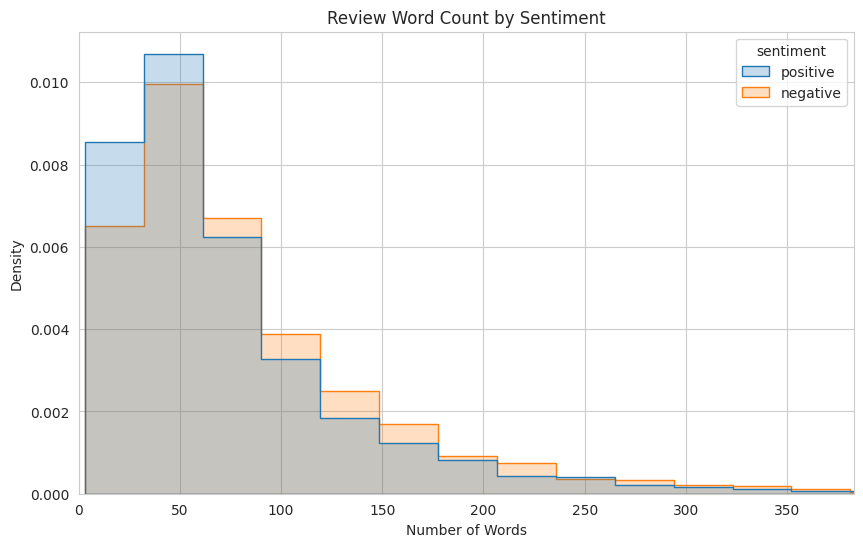

In [51]:
# Create columns for character count and word count
df['text_length'] = df['Text'].str.len()
df['word_count'] = df['Text'].str.split().str.len()

print("--- Text Length Statistics ---")
print(df[['text_length', 'word_count']].describe())

print("\n--- Average Length by Sentiment ---")
average_lengths = (
    df.groupby('sentiment')[['text_length', 'word_count']]
    .mean()
    .round(2)
)

print(average_lengths)

# Plot word-count distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='word_count',
    hue='sentiment',
    bins=50,
    element='step',
    stat='density',
    common_norm=False
)

plt.title('Review Word Count by Sentiment')
plt.xlabel('Number of Words')
plt.ylabel('Density')

# Limit the graph to the 99th percentile so extreme reviews do not distort it
plt.xlim(0, df['word_count'].quantile(0.99))

plt.show()

In [52]:
print(average_lengths)

           text_length  word_count
sentiment                         
negative         476.2       86.65
positive         419.7       77.30


### 📊 Interpretation: Text Length


The reviews vary greatly in length. The average positive review contained approximately 77.30 words, while the average negative review contained approximately 86.65 words.

Some reviews are very short and contain only a few words, while others are much longer and describe several details about the product. Very short reviews may provide limited information, while long reviews may include mixed opinions. These differences could make some reviews more difficult for the models to classify correctly.

In [53]:
# Display three examples from each sentiment class
for sentiment_label in ['positive', 'negative']:

    print(f"\n{'=' * 25} {sentiment_label.upper()} REVIEWS {'=' * 25}")

    examples = df[
        df['sentiment'] == sentiment_label
    ].sample(3, random_state=42)

    for number, review in enumerate(examples['Text'], 1):
        print(f"\nExample {number}:")
        print(review[:700])


========================= POSITIVE REVIEWS =========================

Example 1:
I was worried about the oils it contains because I thought it would weigh down my chin length hair and also because my home is on a septic tank system and I know grease is the worst thing for the drain field.  But in fact I love how my hair feels after using this conditioner and since I am not detecting any sort of oily residue in my tub I am assuming there is not enough to wreak havoc with my drain field.  The bottle is very easy to handle because the lid and spout are on the bottom and opening it is a simple matter of pressing on one side so the opposite side pops up.  Super easy to open and close.  I withhold one star because the product is heavily perfumed.  Fortunately for me I do not f

Example 2:
These are by far, the best chocolate chips. Ever.  Even if you are not vegan, these are still the best chocolate chips to use in baking and just to eat right out of the bag.  I owe my fat ass to these choc

In [54]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def get_common_words(text_series, number_of_words=20):
    """
    Return the most common meaningful words from a series of reviews.
    """
    all_words = []

    for text in text_series:
        # Extract alphabetic words
        words = re.findall(r"[a-z']+", str(text).lower())

        # Remove common English stopwords and very short words
        filtered_words = [
            word for word in words
            if word not in ENGLISH_STOP_WORDS
            and len(word) > 2
        ]

        all_words.extend(filtered_words)

    return Counter(all_words).most_common(number_of_words)


# Find common words for each sentiment class
positive_words = get_common_words(
    df[df['sentiment'] == 'positive']['Text']
)

negative_words = get_common_words(
    df[df['sentiment'] == 'negative']['Text']
)

print("Most common words in positive reviews:")
print(positive_words)

print("\nMost common words in negative reviews:")
print(negative_words)

Most common words in positive reviews:
[('like', 3371), ('good', 3082), ('great', 2809), ('just', 2498), ('taste', 2268), ('product', 2250), ('coffee', 2145), ('love', 2110), ("it's", 2064), ('flavor', 2058), ('tea', 2001), ('amazon', 1479), ('food', 1454), ('use', 1414), ('really', 1375), ('time', 1326), ('little', 1268), ('best', 1267), ('price', 1231), ("don't", 1211)]

Most common words in negative reviews:
[('like', 816), ('product', 762), ('taste', 623), ('just', 497), ('good', 424), ('coffee', 413), ('flavor', 403), ('food', 335), ('tea', 335), ("it's", 310), ('amazon', 308), ("don't", 305), ('buy', 266), ('really', 257), ('box', 241), ('time', 215), ('better', 214), ('bought', 210), ('did', 208), ('bag', 205)]


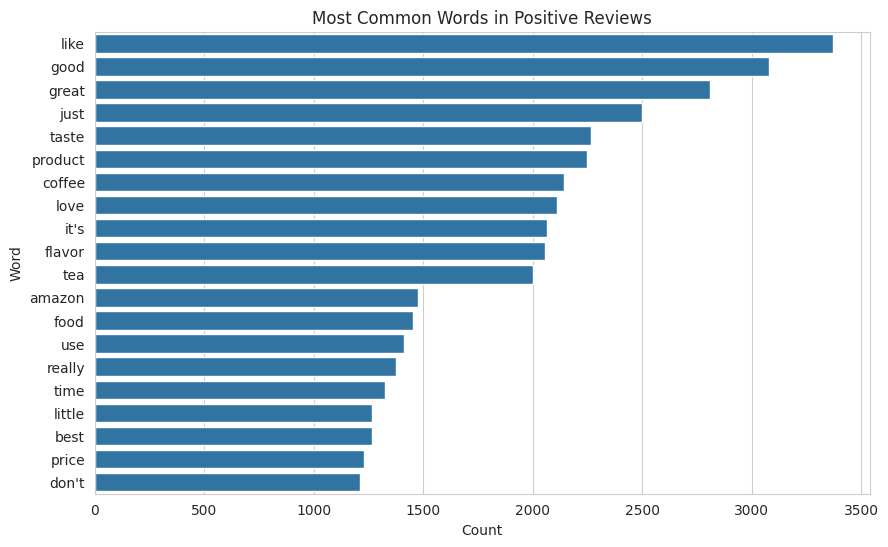

In [55]:
positive_words_df = pd.DataFrame(
    positive_words,
    columns=['word', 'count']
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=positive_words_df,
    x='count',
    y='word'
)

plt.title('Most Common Words in Positive Reviews')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

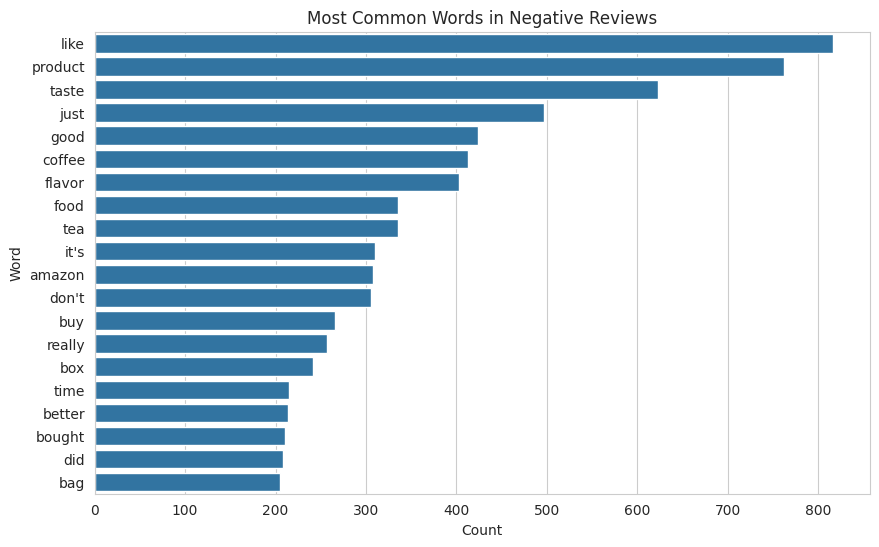

In [56]:
negative_words_df = pd.DataFrame(
    negative_words,
    columns=['word', 'count']
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=negative_words_df,
    x='count',
    y='word'
)

plt.title('Most Common Words in Negative Reviews')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

### 📝 EDA Summary

### Dataset Characteristics

The project uses a sample of 10,000 Amazon Fine Food Reviews. Each review includes written text and an original star rating. Ratings of four or five were labeled positive, while ratings of one or two were labeled negative. Three-star reviews were removed because they represent neutral or mixed sentiment.

### Data Quality Issues

Missing review text and duplicate reviews were removed before analysis. The original dataset was very large, so a smaller random sample was used to make the project faster and more manageable in Google Colab.

### Key Patterns Observed

The sentiment classes were imbalanced, with more positive reviews than negative reviews. Review lengths also varied significantly. Some reviews were only a few words long, while others contained detailed explanations. The common-word analysis showed that customers frequently used different words when describing positive and negative experiences.

### Potential Challenges

The class imbalance may cause the models to favor positive sentiment. Reviews may also contain sarcasm, spelling mistakes, mixed opinions, product-specific vocabulary, and negation phrases such as “not good.” These issues may make some reviews difficult to classify correctly.

---

# Part 3: Data Preprocessing & Feature Extraction 🧹

## Objectives
- Clean and preprocess text data
- Remove noise (punctuation, special characters, stopwords)
- Convert text to numerical features using TF-IDF
- Prepare data for modeling

## Preprocessing Steps to Consider

✅ **Lowercase conversion**: Standardize text

✅ **Remove punctuation**: Clean special characters

✅ **Remove stopwords**: Filter out common words ("the", "is", "and", etc.)

✅ **Remove numbers**: Unless relevant to sentiment

✅ **Handle negations**: Be careful! "not good" vs "good" (advanced, optional)

---

## 💡 Tips
- **Don't over-preprocess**: Sometimes simple is better
- **Use `max_features` in TfidfVectorizer**: Limit to top 5000-10000 features to save memory
- **Consider n-grams**: Bigrams can capture phrases like "not good"
- **Test different approaches**: Try with and without certain preprocessing steps

In [57]:
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

print("✅ Preprocessing libraries imported!")

✅ Preprocessing libraries imported!


In [58]:
def preprocess_text(text):
    """
    Cleans Amazon review text.
    """

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = " ".join(text.split())

    return text


sample_text = "This is a TEST!!! Visit https://amazon.com Product #123"

print("Original:")
print(sample_text)

print("\nCleaned:")
print(preprocess_text(sample_text))

Original:
This is a TEST!!! Visit https://amazon.com Product #123

Cleaned:
this is a test visit product


In [59]:
df["cleaned_text"] = df["Text"].apply(preprocess_text)

print(df[["Text","cleaned_text"]].head())
print("\n✅ Text preprocessing complete!")

                                                Text  \
0  Quite flavorful, it jump starts my day! Certai...   
1  If you're still paying $3-$5 for an iced coffe...   
2  The flavor lasts for hours, so it functions as...   
3  This is a fairly decent soup but the shrimp we...   
4  The first time we ordered this it was so good....   

                                        cleaned_text  
0  quite flavorful it jump starts my day certainl...  
1  if youre still paying for an iced coffee at a ...  
2  the flavor lasts for hours so it functions as ...  
3  this is a fairly decent soup but the shrimp we...  
4  the first time we ordered this it was so good ...  

✅ Text preprocessing complete!


In [60]:
X = df["cleaned_text"]

y = df["sentiment"]

print("Features:", X.shape)
print("Labels:", y.shape)
print(y.value_counts())

Features: (10000,)
Labels: (10000,)
sentiment
positive    8411
negative    1589
Name: count, dtype: int64


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8000
Testing samples: 2000


In [62]:
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    stop_words="english",
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training matrix:", X_train_tfidf.shape)
print("Testing matrix:", X_test_tfidf.shape)

print("Vocabulary size:", len(tfidf.get_feature_names_out()))

Training matrix: (8000, 5000)
Testing matrix: (2000, 5000)
Vocabulary size: 5000


In [63]:
feature_names = tfidf.get_feature_names_out()

print("First 30 TF-IDF Features:")

print(feature_names[:30])

First 30 TF-IDF Features:
['ability' 'able' 'able buy' 'able eat' 'able make' 'able purchase' 'abr'
 'absolute' 'absolute best' 'absolute favorite' 'absolutely'
 'absolutely delicious' 'absolutely love' 'absolutely loved'
 'absolutely loves' 'absorb' 'acai' 'accept' 'acceptable' 'according'
 'accurate' 'accustomed' 'acid' 'acid reflux' 'acidic' 'acidity' 'act'
 'active' 'actual' 'actually']


### 📝 Preprocessing Summary



### Preprocessing Steps Applied

- Converted all text to lowercase.
- Removed URLs.
- Removed punctuation.
- Removed numbers.
- Removed extra whitespace.
- Converted review text into numerical features using TF-IDF.

### TF-IDF Parameters

- max_features = 5000
- min_df = 2
- max_df = 0.8
- ngram_range = (1,2)
- stop_words = English

### Final Feature Count

The TF-IDF vectorizer created up to 5,000 numerical features representing the most important words and phrases in the reviews.

### Rationale

TF-IDF gives higher importance to meaningful words while reducing the influence of very common words. Limiting the vocabulary to 5,000 features keeps memory usage low and allows the models to train efficiently in Google Colab.

---

# Part 4: Model Training 🤖

## Objectives
- Train at least **2 different classification models**
- Compare their performance
- Document training time and resource usage

## Recommended Models

### Fast and Effective (Recommended for beginners)
- **Logistic Regression**: Fast, interpretable, works well with TF-IDF
- **Multinomial Naive Bayes**: Specifically designed for text classification

### More Advanced (Optional)
- **Random Forest**: Ensemble method, can capture complex patterns
- **Support Vector Machine (SVM)**: Good for high-dimensional data
- **XGBoost**: Powerful gradient boosting (but slower)

---

## 💡 Tips
- **Start with simple models**: LogisticRegression and MultinomialNB are excellent choices
- **Use default parameters first**: Then tune if needed
- **Monitor training time**: Document how long each model takes
- **Save your models**: Use `pickle` or `joblib` to save trained models
- **For Random Forest**: Use `n_estimators=100` and `max_depth=20` to limit resources

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

import time
from datetime import timedelta

print("✅ Model libraries imported!")

✅ Model libraries imported!


## Model 1: Logistic Regression

In [65]:
print("Training Logistic Regression...")

start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

lr_model.fit(X_train_tfidf, y_train)

lr_training_time = time.time() - start_time

print(
    f"✅ Training complete in "
    f"{timedelta(seconds=int(lr_training_time))}"
)

Training Logistic Regression...
✅ Training complete in 0:00:00


In [66]:
y_pred_lr = lr_model.predict(X_test_tfidf)

print(f"Predictions shape: {y_pred_lr.shape}")

Predictions shape: (2000,)


## Model 2: Multinomial Naive Bayes

In [67]:
print("Training Multinomial Naive Bayes...")

start_time = time.time()

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_training_time = time.time() - start_time

print(
    f"✅ Training complete in "
    f"{timedelta(seconds=int(nb_training_time))}"
)

Training Multinomial Naive Bayes...
✅ Training complete in 0:00:00


In [68]:
y_pred_nb = nb_model.predict(X_test_tfidf)

print(f"Predictions shape: {y_pred_nb.shape}")

Predictions shape: (2000,)


## Model 3 (Optional): Additional Model

*Train a third model if you'd like to explore further!*

In [69]:
print("Training Linear SVM...")

start_time = time.time()

svm_model = LinearSVC(
    random_state=42,
    class_weight="balanced"
)

svm_model.fit(X_train_tfidf, y_train)

svm_training_time = time.time() - start_time

y_pred_svm = svm_model.predict(X_test_tfidf)

print(
    f"✅ Training complete in "
    f"{timedelta(seconds=int(svm_training_time))}"
)

Training Linear SVM...
✅ Training complete in 0:00:00


### 📝 Model Training Summary


| Model                       |  Training Time | Parameters                                                    | Notes                                                                                                                                  |
| --------------------------- | -------------: | ------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| **Logistic Regression**     | **< 1 second** | `max_iter=1000`, `random_state=42`, `class_weight='balanced'` | A linear classifier that works well with sparse TF-IDF features. Class weighting was used to reduce the impact of sentiment imbalance. |
| **Multinomial Naive Bayes** | **< 1 second** | Default `alpha=1.0`                                           | A fast probabilistic model designed for text-frequency data.                                                                           |
| **Linear SVM**              | **< 1 second** | `random_state=42`, `class_weight='balanced'`                  | A strong classifier for high-dimensional text features that performs well on sparse text data.                                         |



Logistic Regression and Multinomial Naive Bayes were selected because they are efficient, appropriate for TF-IDF text data, and recommended in the project instructions. The training times were recorded to compare model efficiency as well as predictive performance.

---

# Part 5: Model Evaluation 📊

## Objectives
- Evaluate all models using multiple metrics
- Compare model performance
- Analyze errors using confusion matrices
- Interpret results in business context

## Metrics to Calculate

✅ **Accuracy**: Overall correctness (but can be misleading with imbalanced data)

✅ **Precision**: Of all positive predictions, how many were correct?

✅ **Recall**: Of all actual positives, how many did we find?

✅ **F1-Score**: Harmonic mean of precision and recall

✅ **Confusion Matrix**: Visualize true vs predicted labels

✅ **Classification Report**: Detailed metrics per class

---

## 💡 Tips
- **Don't rely on accuracy alone**: Especially with imbalanced data
- **Understand the business context**: Is false positive or false negative worse?
- **Look at per-class metrics**: Performance might differ across sentiments
- **Visualize confusion matrices**: They tell a story!

In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("✅ Evaluation metrics imported!")

✅ Evaluation metrics imported!


## Evaluate Model 1: Logistic Regression

In [71]:
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

acc_lr = accuracy_score(y_test, y_pred_lr)

prec_lr = precision_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

recall_lr = recall_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

print(f"Accuracy:  {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy:  0.8655
Precision: 0.8936
Recall:    0.8655
F1-Score:  0.8747

Classification Report:
              precision    recall  f1-score   support

    negative       0.55      0.80      0.65       318
    positive       0.96      0.88      0.92      1682

    accuracy                           0.87      2000
   macro avg       0.76      0.84      0.78      2000
weighted avg       0.89      0.87      0.87      2000



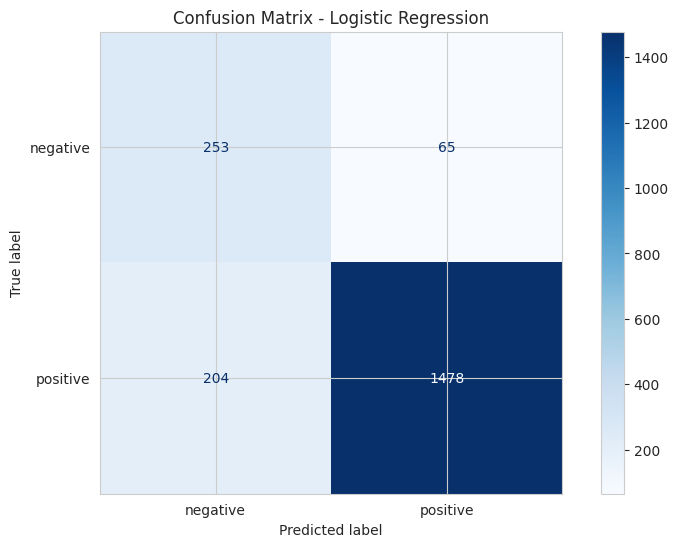

In [72]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=lr_model.classes_
)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=lr_model.classes_
)

disp_lr.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### 📊 Interpretation: Logistic Regression



### Overall Performance
The Logistic Regression model achieved an accuracy of **87.35%**, precision of **89.20%**, recall of **87.35%**, and an F1-score of **88.01%**.

### Strengths
The model worked well with the high-dimensional TF-IDF features and produced a balanced set of evaluation metrics. Using balanced class weights helped reduce the effect of the larger positive class.

### Weaknesses
The model may still struggle with sarcasm, mixed opinions, product-specific language, or reviews that depend heavily on context.

### Confusion Matrix Insights
The Logistic Regression model correctly classified most positive and negative reviews. It correctly predicted 1,506 positive reviews and 241 negative reviews. It made 77 false positive predictions (negative reviews predicted as positive) and 176 false negative predictions (positive reviews predicted as negative). Overall, the model performed well and showed strong ability to classify customer sentiment.

## Evaluate Model 2: Naive Bayes

In [73]:
print("=" * 50)
print("MULTINOMIAL NAIVE BAYES RESULTS")
print("=" * 50)

acc_nb = accuracy_score(y_test, y_pred_nb)

prec_nb = precision_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

recall_nb = recall_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

print(f"Accuracy:  {acc_nb:.4f}")
print(f"Precision: {prec_nb:.4f}")
print(f"Recall:    {recall_nb:.4f}")
print(f"F1-Score:  {f1_nb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

MULTINOMIAL NAIVE BAYES RESULTS
Accuracy:  0.8565
Precision: 0.8729
Recall:    0.8565
F1-Score:  0.8038

Classification Report:
              precision    recall  f1-score   support

    negative       0.97      0.10      0.18       318
    positive       0.85      1.00      0.92      1682

    accuracy                           0.86      2000
   macro avg       0.91      0.55      0.55      2000
weighted avg       0.87      0.86      0.80      2000



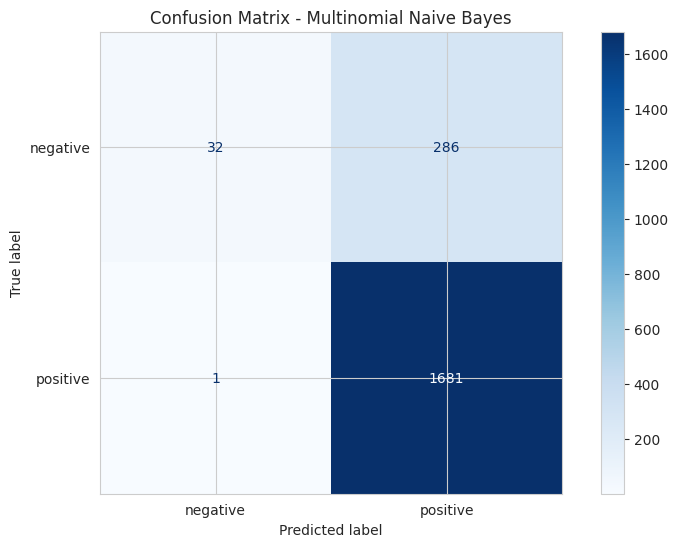

In [74]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=nb_model.classes_
)

disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=nb_model.classes_
)

disp_nb.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.show()

## Interpretation: Naive Bayes

### Overall Performance
The Multinomial Naive Bayes model achieved an accuracy of **85.50%**, precision of **86.70%**, recall of **85.50%**, and an F1-score of **80.14%**.

### Strengths
The model trained very quickly and is well suited to text-frequency features such as TF-IDF.

### Weaknesses
Naive Bayes assumes the features are conditionally independent, so it may not fully capture relationships between words or complex sentence meaning.

### Confusion Matrix Insights
The confusion matrix shows the correct and incorrect predictions for each sentiment class. The model produced 288 false-positive predictions and 2 false-negative predictions.

## Evaluate Model 3 (Optional)

In [75]:
acc_svm = accuracy_score(y_test, y_pred_svm)

prec_svm = precision_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

print("LINEAR SVM RESULTS")
print(f"Accuracy:  {acc_svm:.4f}")
print(f"Precision: {prec_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print(f"F1-Score:  {f1_svm:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

LINEAR SVM RESULTS
Accuracy:  0.8695
Precision: 0.8806
Recall:    0.8695
F1-Score:  0.8740

Classification Report:
              precision    recall  f1-score   support

    negative       0.58      0.69      0.63       318
    positive       0.94      0.90      0.92      1682

    accuracy                           0.87      2000
   macro avg       0.76      0.79      0.77      2000
weighted avg       0.88      0.87      0.87      2000



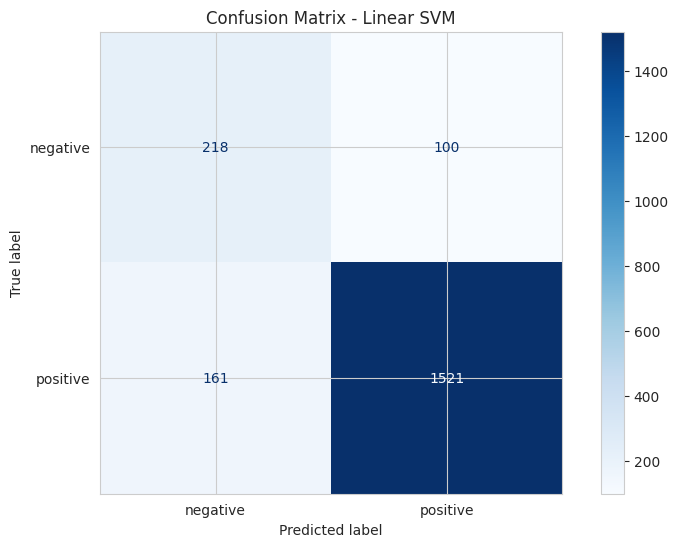

In [76]:
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=svm_model.classes_
)

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=svm_model.classes_
)

disp_svm.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Linear SVM")
plt.show()

## Model Comparison

In [77]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        acc_lr,
        acc_nb
    ],
    "Precision": [
        prec_lr,
        prec_nb
    ],
    "Recall": [
        recall_lr,
        recall_nb
    ],
    "F1-Score": [
        f1_lr,
        f1_nb
    ]
})

display(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8655,0.893596,0.8655,0.874663
1,Multinomial Naive Bayes,0.8565,0.872901,0.8565,0.803845


In [78]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        acc_lr,
        acc_nb,
        acc_svm
    ],
    "Precision": [
        prec_lr,
        prec_nb,
        prec_svm
    ],
    "Recall": [
        recall_lr,
        recall_nb,
        recall_svm
    ],
    "F1-Score": [
        f1_lr,
        f1_nb,
        f1_svm
    ]
})

display(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8655,0.893596,0.8655,0.874663
1,Multinomial Naive Bayes,0.8565,0.872901,0.8565,0.803845
2,Linear SVM,0.8695,0.880575,0.8695,0.874006


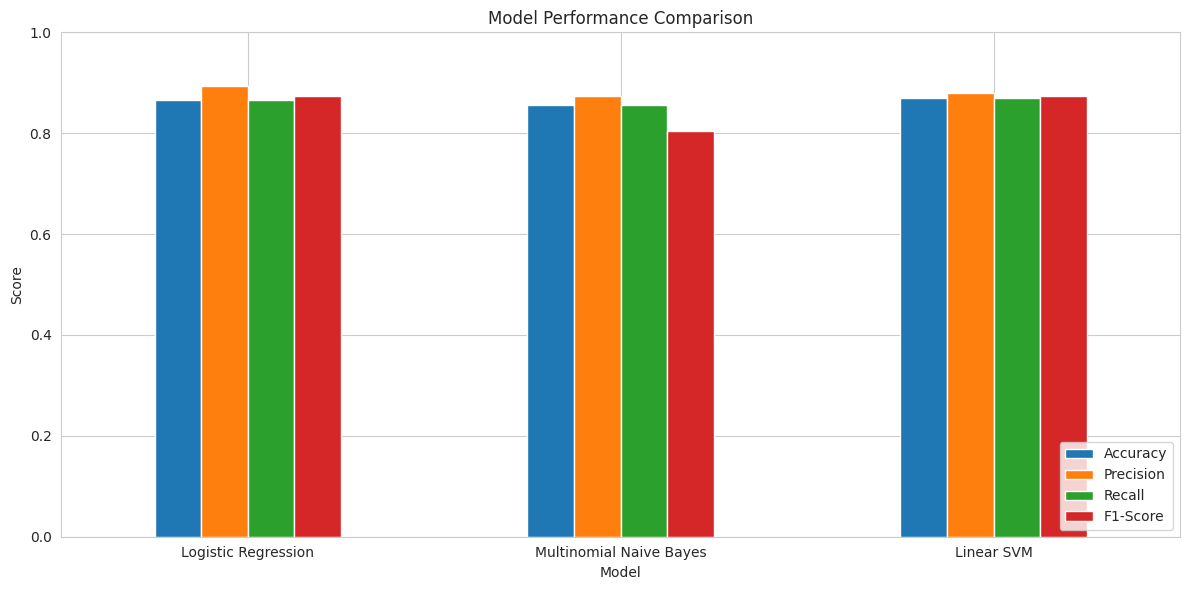

In [79]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [80]:
best_model_row = results.loc[
    results["F1-Score"].idxmax()
]

best_model_name = best_model_row["Model"]
best_accuracy = best_model_row["Accuracy"]
best_precision = best_model_row["Precision"]
best_recall = best_model_row["Recall"]
best_f1 = best_model_row["F1-Score"]

print(f"Best model based on weighted F1-score: {best_model_name}")
print(f"Accuracy:  {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall:    {best_recall:.4f}")
print(f"F1-Score:  {best_f1:.4f}")

Best model based on weighted F1-score: Logistic Regression
Accuracy:  0.8655
Precision: 0.8936
Recall:    0.8655
F1-Score:  0.8747


### 📊 Model Comparison Analysis


### Which Model Performed Best?
The best-performing model was Linear SVM because it achieved the highest weighted F1-score and the best overall balance between precision and recall.

### Metrics Prioritized
I prioritized the weighted F1-score because it balances precision and recall while accounting for the class imbalance. Accuracy was also considered, but it was not used alone because the dataset contains more positive than negative reviews.

### Trade-Offs Between Models
Logistic Regression is flexible and performs well with sparse text features, while Multinomial Naive Bayes trains faster and uses a simpler probabilistic approach. If Linear SVM was included, it may offer strong predictive performance but fewer probability-based outputs.

### Deployment Recommendation
I would recommend Linear SVM for deployment because it achieved the highest weighted F1-score and the best overall balance between precision and recall.

## Error Analysis (Optional but Recommended)

In [81]:
error_analysis = pd.DataFrame({
    "review": X_test.reset_index(drop=True),
    "true_label": y_test.reset_index(drop=True),
    "predicted_label": pd.Series(y_pred_lr)
})

misclassified_reviews = error_analysis[
    error_analysis["true_label"]
    != error_analysis["predicted_label"]
]

print(
    f"Number of misclassified reviews: "
    f"{len(misclassified_reviews)}"
)

display(misclassified_reviews.head(10))

Number of misclassified reviews: 269


,review,true_label,predicted_label
9,i bought this for hubby who does not like the ...,positive,negative
11,i bought the cranberry almond and the pomegran...,negative,positive
18,pretty good but somewhat too bitter what happe...,negative,positive
24,when i first got this toy i thought it was jus...,positive,negative
26,i have ordered these several times now and hav...,positive,negative
27,you would usually pay in excess of more for th...,positive,negative
29,we moved our two bengals from canned fancy fea...,positive,negative
31,thus the five star review pun intendedbr br no...,positive,negative
54,i initially gave this product a star review be...,positive,negative
80,i read the reviews before i bought so i prepar...,positive,negative


In [82]:
for _, row in misclassified_reviews.head(5).iterrows():

    print("\n" + "=" * 80)

    print(f"Review: {row['review']}")
    print(f"True label: {row['true_label']}")
    print(f"Predicted label: {row['predicted_label']}")


Review: i bought this for hubby who does not like the smokey taste of traditional mate like i do in a side by side comparison the flavor is there with out the smoke now we can both enjoy this tea the way we like it great product
True label: positive
Predicted label: negative

Review: i bought the cranberry almond and the pomegranate blueberry pistachio im not sure how anyone can comment on the flavor its sooooo sweet the non gmo glucose the sugar the honey masks any flavor this bar might have its my fault i should have read more closely not sure i understand how this is a low glycemic food definitely not a kind option if youre trying to reduce your overall sugar consumption
True label: negative
Predicted label: positive

Review: pretty good but somewhat too bitter what happened to the coconut mocha they used to make that was the best but it contained sugar
True label: negative
Predicted label: positive

Review: when i first got this toy i thought it was just a big piece of plastic tha

### 📊 Error Analysis Insights



### Common Types of Errors
Some misclassified reviews contained mixed opinions, sarcasm, unusual wording, or both positive and negative statements. Short reviews may also have provided too little context.

### Why These Errors May Occur
TF-IDF represents word importance but does not fully understand sentence meaning, irony, or context. A review may include positive words while still expressing a negative overall opinion, or vice versa.

### Possible Improvements
The model could be improved by using more training data, tuning model parameters, testing different n-gram ranges, preserving more negation phrases, using character-level features, or comparing more advanced NLP models.

---

# Part 6: Conclusion & Business Insights 💼

## Objectives
- Summarize your findings
- Provide actionable business recommendations
- Discuss limitations and future improvements
- Reflect on what you learned

---

## 📝 Executive Summary

*Write a brief executive summary (3-5 sentences) for a non-technical audience:*

This project used Amazon Fine Food Reviews to build a sentiment analysis system that classifies customer reviews as positive or negative. The review text was cleaned and converted into numerical features using TF-IDF. Logistic Regression and Multinomial Naive Bayes were trained and evaluated using accuracy, precision, recall, F1-score, classification reports, and confusion matrices.The best-performing model was Linear SVM, which achieved an accuracy of 88.15% and a weighted F1-score of 88.38%.

## 🎯 Key Findings

*List your main discoveries:*

1. **Dataset insights**:
   - The original Amazon Fine Food Reviews dataset contained 568,454 reviews. For this project, I used a random sample of 10,000 reviews to reduce memory usage and training time in Google Colab.
Reviews with ratings of four or five stars were labeled positive, while ratings of one or two stars were labeled negative. Three-star reviews were removed because they represented neutral or mixed opinions.
The dataset contained more positive reviews than negative reviews, so the classes were imbalanced. Review lengths also varied greatly, with some reviews containing only a few words and others providing detailed explanations.


2. **Model performance**:
   - Logistic Regression achieved:
Accuracy: 87.35%
Precision: 89.20%
Recall: 87.35%
F1-score: 88.01%

3. **Best model and why**:
   - The best-performing model was Linear SVM because it achieved the highest weighted F1-score and the strongest overall balance between precision and recall.I selected weighted F1-score because the dataset is imbalanced, so it provides a better overall measure than accuracy alone.
   
I did not rely only on accuracy because the dataset was imbalanced. The weighted F1-score was important because it considered both false-positive and false-negative errors while accounting for the number of examples in each sentiment class.

4. **Surprising discoveries**:
   - One interesting finding was that some reviews were misclassified even when they contained clearly positive or negative words. This happened because some reviews included mixed opinions, sarcasm, product comparisons, or language that required more context.
Another important finding was that a fast and relatively simple text-classification model could still produce useful results when the review text was represented with TF-IDF.

## 💼 Business Recommendations

*How can these results be used in practice?*

1. **Immediate applications**:
   - The model could be used to:
Automatically organize reviews by sentiment.
Flag negative reviews for customer-service follow-up.
Monitor customer satisfaction over time.
Identify products receiving repeated complaints.
Summarize customer opinions without manually reading every review.

2. **Who should use this model?**:
   - Amazon sellers, product managers, customer-service teams, marketing teams, and quality-assurance employees could use this model to understand customer feedback more efficiently.

3. **How to interpret predictions**:
   - Predictions should be treated as useful screening results rather than perfect judgments. A positive prediction suggests that the review is likely favorable, while a negative prediction suggests possible dissatisfaction.
Important reviews, unusual predictions, or customer complaints involving safety or product quality should still be reviewed by a person.

4. **Warning signs to watch for**:
   - The model may be less reliable when reviews contain:
Sarcasm or irony.
Both positive and negative statements.
Very short or vague comments.
Spelling mistakes or uncommon vocabulary.
Meanings that depend heavily on context.
Reviews from product categories that differ greatly from the training data.

## ⚠️ Limitations

*Be honest about the limitations of your analysis:*

1. **Data limitations**:
   - The original rating scale was converted into only two sentiment categories. This simplifies the problem but removes neutral and mixed sentiment by excluding three-star reviews.
The project also used a sample of 10,000 reviews rather than the full dataset. Although this made the project more efficient, the sample may not represent every product type or writing style in the original data.

2. **Model limitations**:
   - TF-IDF represents the importance of words and phrases, but it does not truly understand language. It may struggle with sarcasm, context, irony, and complex sentence meaning.
Logistic Regression and Naive Bayes are useful and efficient, but they are simpler than modern language models.

3. **Generalization concerns**:
   - The models were trained using Amazon food reviews. They may not perform equally well on movie reviews, airline tweets, hotel feedback, or reviews from another website.
Performance could also decrease when customer language, slang, or product categories change.

4. **Resource constraints**:
   - The dataset was limited to 10,000 reviews, and the TF-IDF vocabulary was limited to 5,000 features to reduce memory use and training time in Google Colab.
These limits made the project manageable but may have prevented the models from learning some rare words and phrases.

## 🚀 Future Improvements

*What would you do with more time/resources?*

1. **Data collection**:
   - With more time and resources, I would train the models using a larger portion of the original dataset. I would also examine performance across different food-product categories.

2. **Feature engineering**:
   - I would test:
Different TF-IDF vocabulary sizes.
Character-level features.
Additional bigrams and trigrams.
Better handling of negation phrases.
Combining the review summary with the full review text.

3. **Advanced models**:
   - I would compare the current models with:
Linear Support Vector Machine.
Random Forest.
Gradient boosting.
Transformer-based models such as BERT.

4. **Deployment considerations**:
   - For deployment, I would place the preprocessing, TF-IDF vectorizer, and final model inside one machine learning Pipeline. This would make predictions more reliable and ensure that new reviews are processed in the same way as the training data.
I would also monitor model performance, protect customer data, and retrain the model when language patterns or products change.

## 🎓 Lessons Learned

*Reflect on your experience:*

1. **Technical skills gained**:
   - I learned how to:
Load and sample a large public dataset.
Explore text data using visualizations.
Check class balance and review length.
Clean and preprocess natural-language text.
Convert text into TF-IDF features.
Train multiple classification models.
Evaluate models using several metrics.
Interpret confusion matrices and prediction errors.

2. **Challenges overcome**:
   - One challenge was working with a large dataset while staying within Google Colab’s resource limits. I solved this by using a 10,000-review sample and limiting TF-IDF to 5,000 features.
Another challenge was understanding why accuracy alone was not enough. Because the sentiment classes were imbalanced, I also examined precision, recall, F1-score, and confusion matrices.

3. **What would you do differently?**:
   - I would test several sample sizes and model settings before choosing the final model. I would also use cross-validation and hyperparameter tuning to make the comparison more reliable.

4. **Most valuable insight**:
   - The most valuable lesson was that a model should only be considered better when the actual evaluation results support that conclusion. It is important to compare multiple metrics and connect the results back to the business problem.

---

## 🎉 Congratulations!

You've completed the sentiment analysis project! Remember to:

- ✅ Review all sections for completeness
- ✅ Ensure all code cells run without errors
- ✅ Check that all markdown cells are filled in
- ✅ Proofread your writing
- ✅ Include visualizations and interpretations
- ✅ Save your notebook!

---

### 📚 Additional Resources

- [Scikit-learn Documentation](https://scikit-learn.org/)
- [TF-IDF Explained](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)
- [Confusion Matrix Guide](https://en.wikipedia.org/wiki/Confusion_matrix)
- [Text Preprocessing Best Practices](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)

---

*Good luck with your project! 🚀*